In [9]:
from parselog import *
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import multiprocessing
from collections import defaultdict
from cycler import cycler
import matplotlib as mpl

In [10]:
def calcConfidenceAndDepth(
    benchmark,
    run="cap_chaser_final_large", 
    prefetcherLocation="cap_chaser_split-l1ll",
    silent = True,
):
    pickleFile = f"results/pickles/confidenceAndDepthData/{run}-{prefetcherLocation}-{benchmark.lower()}.pickle"
    if not os.path.isfile(pickleFile):

        confidences = defaultdict(dict)
        depths = {}

        lp = LogParser(
            log=f"results/{run}-{prefetcherLocation}/{benchmark.lower()}/sim_stdout.gz",
            lineTypesToPrune=[None, NonRVFILine], 
            # If a timestamped line matches, then either RVFILine or NonRVFILine will match
            lineTypesToError=[TimestampedLine],
            RootLogLine=TimestampedLine,
            maxLines=None,
            silent=silent
            #startWhen=(lambda ll: isinstance(ll, RVFILine) and ll.rvfi >= 10000),
        )

        depthGroupSize = int(lp.totals[CapChaserTLBResponseLine]["total"] / 500) if CapChaserTLBResponseLine in lp.totals else None
        depthSum = 0
        depthCount = 0

        for ll in lp.logLines:
            if isinstance(ll, CapChaserBroadcastLine):
                confidences[ll.ptIdxTag][ll.timestamp] = ll.confidence/128
            if isinstance(ll, CapChaserTLBResponseLine):
                depthSum += ll.depth
                depthCount += 1
                if depthCount == depthGroupSize:
                    depths[ll.timestamp] = depthSum/depthGroupSize
                    depthSum = 0
                    depthCount = 0

        with open(pickleFile, "wb") as fp:
            pickle.dump((confidences, depths), fp)


def plotConfidenceAndDepth(
    benchmark,
    run="cap_chaser_final_large", 
    prefetcherLocation="cap_chaser_split-l1ll",
    confNumGroups=200,
    plotDepth=False,
    truncationLines=True
):
    confidences = defaultdict(dict)
    depths = {}

    pickleFile = f"results/pickles/confidenceAndDepthData/{run}-{prefetcherLocation}-{benchmark.lower()}.pickle"
    print(pickleFile)
    assert(os.path.isfile(pickleFile))
    with open(pickleFile, "rb") as fp:
        confidences, depths = pickle.load(fp)

    minT = min(t for x in confidences.values() for t in x.keys())
    print(minT)

    fig, axs = plt.subplots(2 if plotDepth else 1, 1, sharex=False, dpi=150, figsize=(6, 3.5 if plotDepth else 2.5))
    if not plotDepth:
        axs = (axs, None)
    ax1, ax2 = axs
    earliestTimeFraction = 1
    for ptIdxTag, confs in confidences.items():
        if len(confs) < 50: 
            continue
        confGroupSize = max(1, int(len(confs)/confNumGroups))
        groupedConfs = {}
        accumulatedConfs = 0
        groupStartTime = None
        for i, (t, c) in enumerate(confs.items()):
            if not groupStartTime:
                groupStartTime = t
            accumulatedConfs += c
            if (i+1) % confGroupSize == 0:
                groupedConfs[(t+groupStartTime)/2] = accumulatedConfs/confGroupSize
                accumulatedConfs = 0
                groupStartTime = None
        groupedItems = list(groupedConfs.items())
        chunkedConfs = [{groupedItems[0][0]: groupedItems[0][1]}]
        totalTime = groupedItems[-1][0]-groupedItems[0][0]
        lastTime = groupedItems[0][0]
        earliestTimeFraction = min(groupedItems[0][0]/totalTime, earliestTimeFraction)
        for t, c in groupedItems[1:]:
            if (t-lastTime)/totalTime > 0.05:
                chunkedConfs.append({})
            chunkedConfs[-1][t] = c
            lastTime = t
        color = None
        for c in chunkedConfs:
            line, = ax1.plot(
                list(t / 1000000. for t in c.keys()), 
                list(c.values()), 
                marker="", 
                linestyle="-", 
                label=(hex(ptIdxTag) if color is None else None), 
                alpha=0.5, 
                linewidth=1.0,
                color=color,
                zorder=0
            )
            color = line.get_color()
        ax1.set_ylim(0, 1)
        ax1.set_ylabel("Per-pointer\nconfidence")
    if plotDepth:
        ax2.plot(
            list(t / 1000000. for t in depths.keys()), 
            list(d+1 for d in depths.values()), 
            marker=None, 
            linestyle="-", 
            color="#505050",
            alpha=1,
            linewidth=1,
            zorder=0
        )
        ax2.set_ylim(1)
        ax2.set_xlabel("Time (10⁶ cycles)")
        ax2.set_ylabel("Average prefetch\nchain length", labelpad=14)
    for ax in axs:
        if ax is None:
            continue
        if earliestTimeFraction < 0.2:
            ax.set_xlim(0)
        else:
            xmin, xmax = ax.get_xlim()
            ax.margins(x=0.09)
            ax.set_xlim(xmax=xmax)
            if truncationLines:
                dx=0.003
                dy=0.07
                x=0.02
                ax.plot((x-dx, x+dx), (-dy, dy), transform=ax.transAxes, color='k', clip_on=False)        # top-left diagonal
                ax.plot((x+3*dx, x+5*dx), (-dy, +dy), transform=ax.transAxes, color='k', clip_on=False)  # top-right diagonal
            #if ax.transAxes.inverted().transform(ax.transData.transform((ax.get_xticks()[0] , 0)))[0] < x*2:
            #    ax.set_xticks(ax.get_xticks()[1:])        
    fig.suptitle(benchmark)
    #fig.legend()
    #fig.tight_layout()
    fig.show()

    return fig, axs

In [11]:
BENCHMARKS = [
    "BH",
    "Bisort",
    #"dijkstra",
    #"dijkstra_capchain",
    "EM3D",
    "Health",
    "Patricia",
    "Perimeter",
    "Power",
    "Treeadd",
    "Treeadd_frag",
    "TSP",
]

with multiprocessing.Pool(processes=16) as pool:
    pool.map(calcConfidenceAndDepth, BENCHMARKS)

results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-bh.pickle
211208
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-bisort.pickle
3914725
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-em3d.pickle
963468
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-health.pickle
1308602
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-patricia.pickle
31118
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-perimeter.pickle
1702160
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-power.pickle
357947
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-treeadd.pickle
3663947
results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-treeadd_frag.pickle
5424917
results/pickles/confidenceAndDepthData/cap_cha

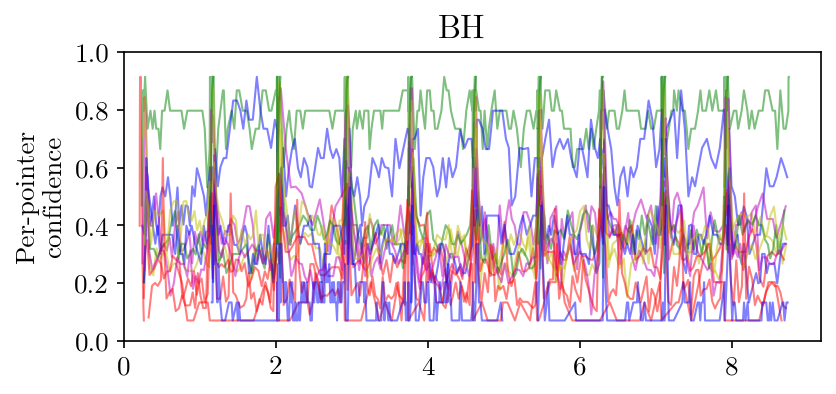

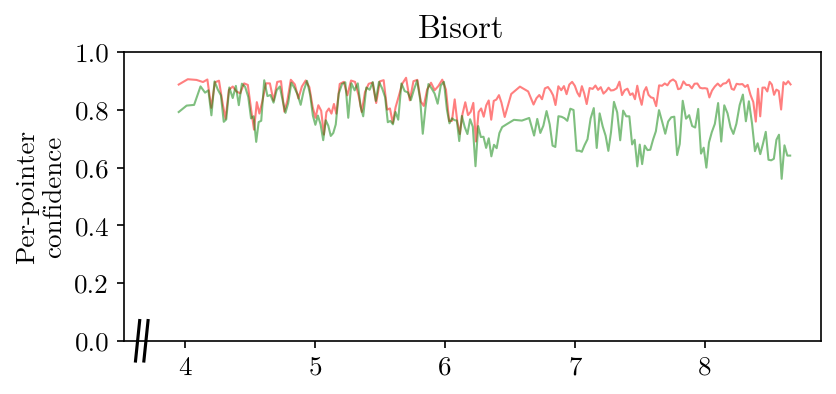

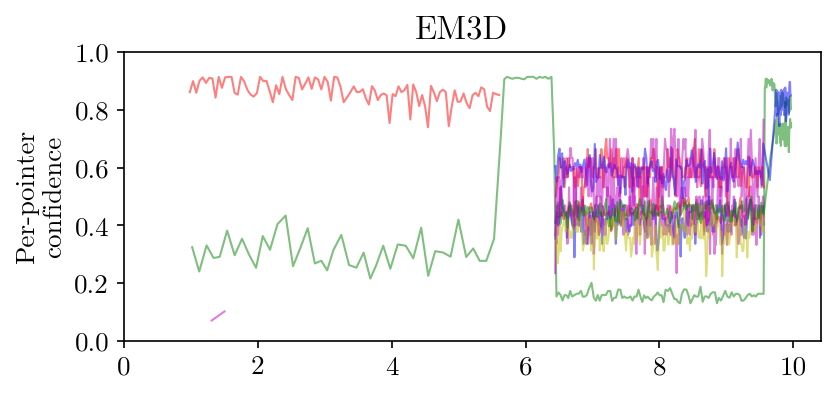

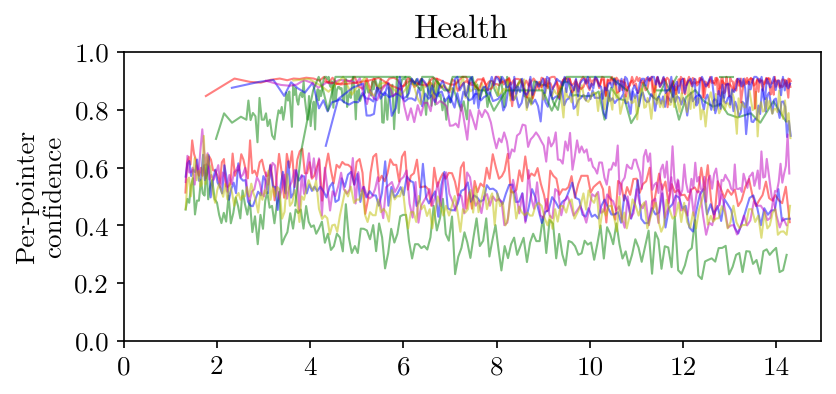

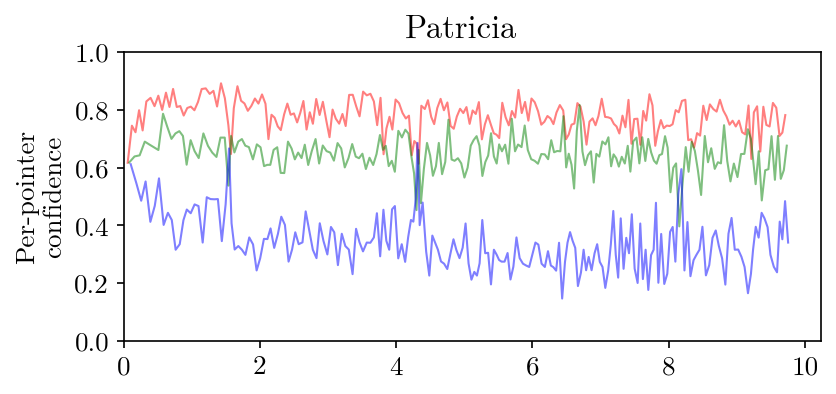

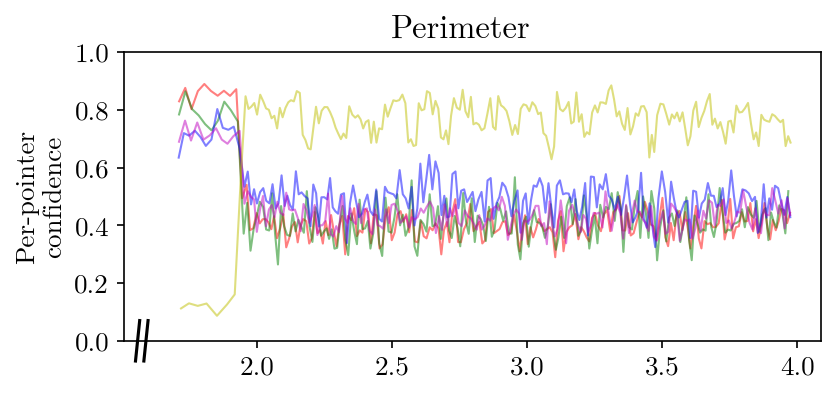

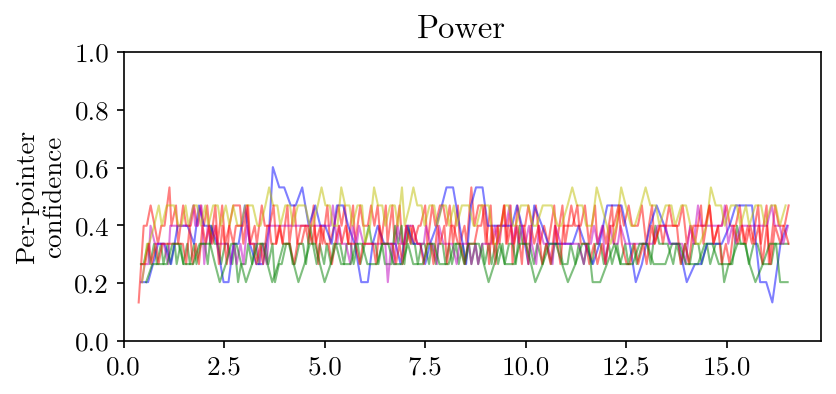

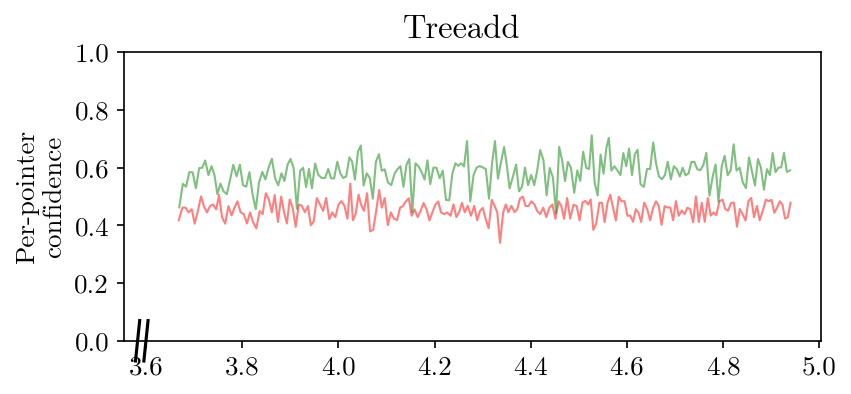

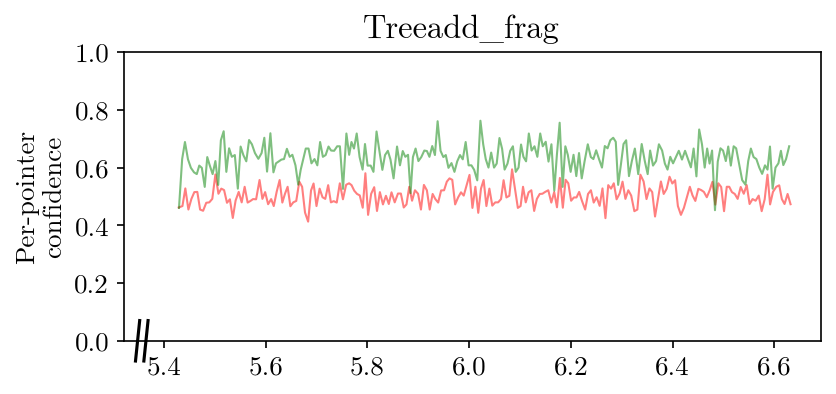

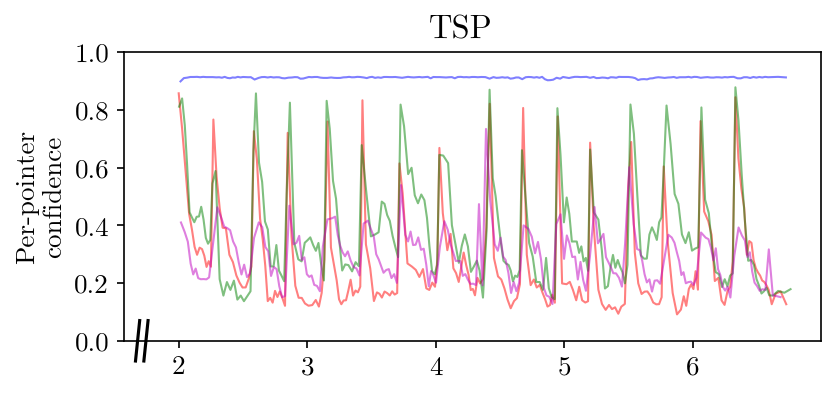

In [12]:
for benchmark in BENCHMARKS:
    plotConfidenceAndDepth(benchmark)

results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-perimeter.pickle
1702160


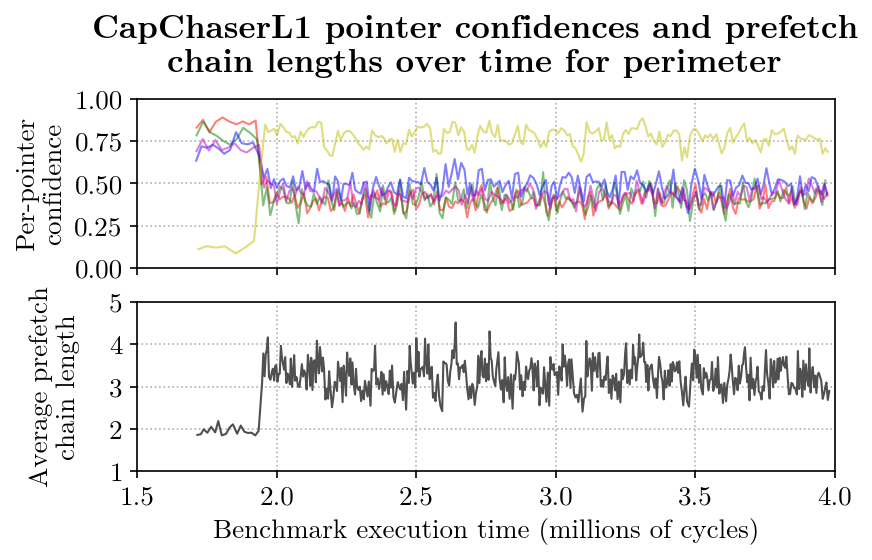

In [13]:
mpl.rcParams['axes.prop_cycle'] = cycler(color='rgbmy')

plt.rcParams.update({"font.family": "Latin Modern Roman"})
plt.rcParams.update({'font.size': 13})
def setTickFont(ax):
    for label in ax.get_xticklabels():
        label.set_fontproperties("Latin Modern Mono Light")

fig, (ax1, ax2) = plotConfidenceAndDepth("perimeter", truncationLines=False, plotDepth=True)
fig.suptitle("CapChaserL1 pointer confidences and prefetch\nchain lengths over time for perimeter", weight="bold")
ax2.set_xlabel("Benchmark execution time (millions of cycles)")
ax1.set_xlim(1.5, 4)
ax2.set_xlim(1.5, 4)
ax2.set_yticks([1, 2, 3, 4, 5])
ax1.set_yticks([0.0, 0.25, 0.5, 0.75, 1])
ax1.set_xticklabels([])
ax1.grid(linestyle=":", zorder=-1)
ax2.grid(linestyle=":", zorder=-1)
ax1.yaxis.set_zorder(-1)
ax1.xaxis.set_zorder(-1)
ax2.yaxis.set_zorder(-1)
ax2.xaxis.set_zorder(-1)
fig.subplots_adjust(top=0.82)
fig.savefig("figures/Final-Olden-Perimeter-Confidences.pdf", bbox_inches='tight')

results/pickles/confidenceAndDepthData/cap_chaser_final_large-cap_chaser_split-l1ll-perimeter.pickle
1702160


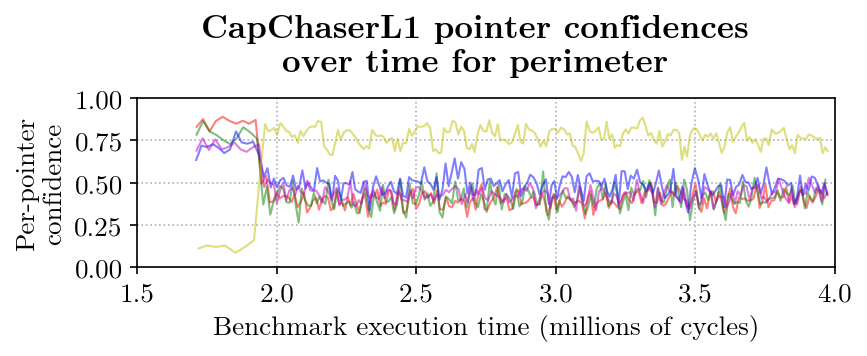

In [17]:
mpl.rcParams['axes.prop_cycle'] = cycler(color='rgbmy')

plt.rcParams.update({"font.family": "Latin Modern Roman"})
plt.rcParams.update({'font.size': 13})
def setTickFont(ax):
    for label in ax.get_xticklabels():
        label.set_fontproperties("Latin Modern Mono Light")

fig, (ax1, ax2) = plotConfidenceAndDepth("perimeter", truncationLines=False, plotDepth=True)
fig.suptitle("CapChaserL1 pointer confidences\nover time for perimeter", weight="bold")
ax1.set_xlabel("Benchmark execution time (millions of cycles)")
ax1.set_xlim(1.5, 4)
ax1.set_yticks([0.0, 0.25, 0.5, 0.75, 1])
ax1.grid(linestyle=":", zorder=-1)
ax1.yaxis.set_zorder(-1)
ax1.xaxis.set_zorder(-1)
fig.subplots_adjust(top=0.82)
ax2.remove()
fig.savefig("figures/Final-Olden-Perimeter-Confidences-Only.pdf", bbox_inches='tight')